# Notebook 01 — Baseline Exploratory Data Analysis
### Population Drift in Deployed AI Medical Devices
**Datasets:** Pima Indians Diabetes (n=768) · Frankfurt Hospital Glucose Dataset (n=2,000)

This notebook performs a unified EDA for both cohorts:
1. Structural cleaning — replacing impossible zero-values with `NaN`
2. Missingness indicator creation + median imputation
3. Distributional profiling, class balance, correlation, outlier analysis
4. Statistical significance tests (T-test + K-S) between diabetic/healthy groups

**Outputs saved:**  `data/interim/{dataset}_step1_clean.csv` · `data/interim/{dataset}_step2_imputed.csv`

In [1]:
# ================================================================
# IMPORTS
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from math import ceil
from scipy.stats import ttest_ind, ks_2samp
import warnings
warnings.filterwarnings('ignore')

pd.set_option('future.no_silent_downcasting', True)
print("All imports successful.")

All imports successful.


In [2]:
# ================================================================
# CONFIGURATION — Update raw data paths if needed
# ================================================================
PROJECT_ROOT = Path().resolve()

DATASET_CONFIGS = {
    'Pima': {
        'raw_path'   : PROJECT_ROOT / 'data' / 'raw' / 'pima_diabetes.csv',
        'interim_tag': 'pima',
        'label'      : 'Pima Indians Diabetes Dataset',
    },
    'FHGD': {
        'raw_path'   : PROJECT_ROOT / 'data' / 'raw' / 'fhgd_diabetes.csv',
        'interim_tag': 'fhgd',
        'label'      : 'Frankfurt Hospital Glucose Dataset (FHGD)',
    },
}

INTERIM_DIR = Path('data/interim')
REPORTS_DIR = Path('reports/eda')
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Biological columns where 0 means missing
ZERO_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Configuration loaded.")
print(f"Interim output dir : {INTERIM_DIR.resolve()}")
print(f"Reports output dir : {REPORTS_DIR.resolve()}")

Configuration loaded.
Interim output dir : D:\Population Drift\MSc-Dissertation-Drift-Detection\notebooks\data\interim
Reports output dir : D:\Population Drift\MSc-Dissertation-Drift-Detection\notebooks\reports\eda


In [3]:
# ================================================================
# HELPER FUNCTIONS
# ================================================================
def fd_bins(x):
    """Freedman-Diaconis adaptive bin count for histograms."""
    x = np.asarray(x.dropna())
    if x.size < 2: return 10
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    if iqr == 0: return 10
    h = 2 * iqr * (x.size ** (-1/3))
    return int(np.clip(np.ceil((x.max() - x.min()) / h), 10, 60))


def save_fig(path, name, dpi=150):
    p = path / f'{name}.png'
    plt.savefig(p, dpi=dpi, bbox_inches='tight')
    print(f'  Saved figure -> {p}')


def save_table(df, path, name):
    p = path / f'{name}.csv'
    df.to_csv(p, index=False)
    print(f'  Saved table  -> {p}')

print("Helper functions defined.")

Helper functions defined.



  DATASET: Pima — Pima Indians Diabetes Dataset

[1] Raw data loaded  | shape: (768, 9)
    Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00



[2] Impossible-zero counts:


,zero_count
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11



[3] step1_clean saved -> data\interim\pima_step1_clean.csv
    Missing values:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0

[4] step2_imputed saved -> data\interim\pima_step2_imputed.csv
    Remaining NaNs: 0

[5] Continuous features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,count,mean,std,min,max,skew
Pregnancies,768.0,3.845,3.370,0.000,17.00,0.902
Glucose,768.0,121.656,30.438,44.000,199.00,0.536
BloodPressure,768.0,72.387,12.097,24.000,122.00,0.142
SkinThickness,768.0,29.108,8.791,7.000,99.00,0.838
Insulin,768.0,140.672,86.383,14.000,846.00,3.380
BMI,768.0,32.455,6.875,18.200,67.10,0.599
DiabetesPedigreeFunction,768.0,0.472,0.331,0.078,2.42,1.920
Age,768.0,33.241,11.760,21.000,81.00,1.130


  Saved table  -> reports\eda\pima\univariate_summary_pima.csv
  Saved figure -> reports\eda\pima\univariate_panels_pima.png


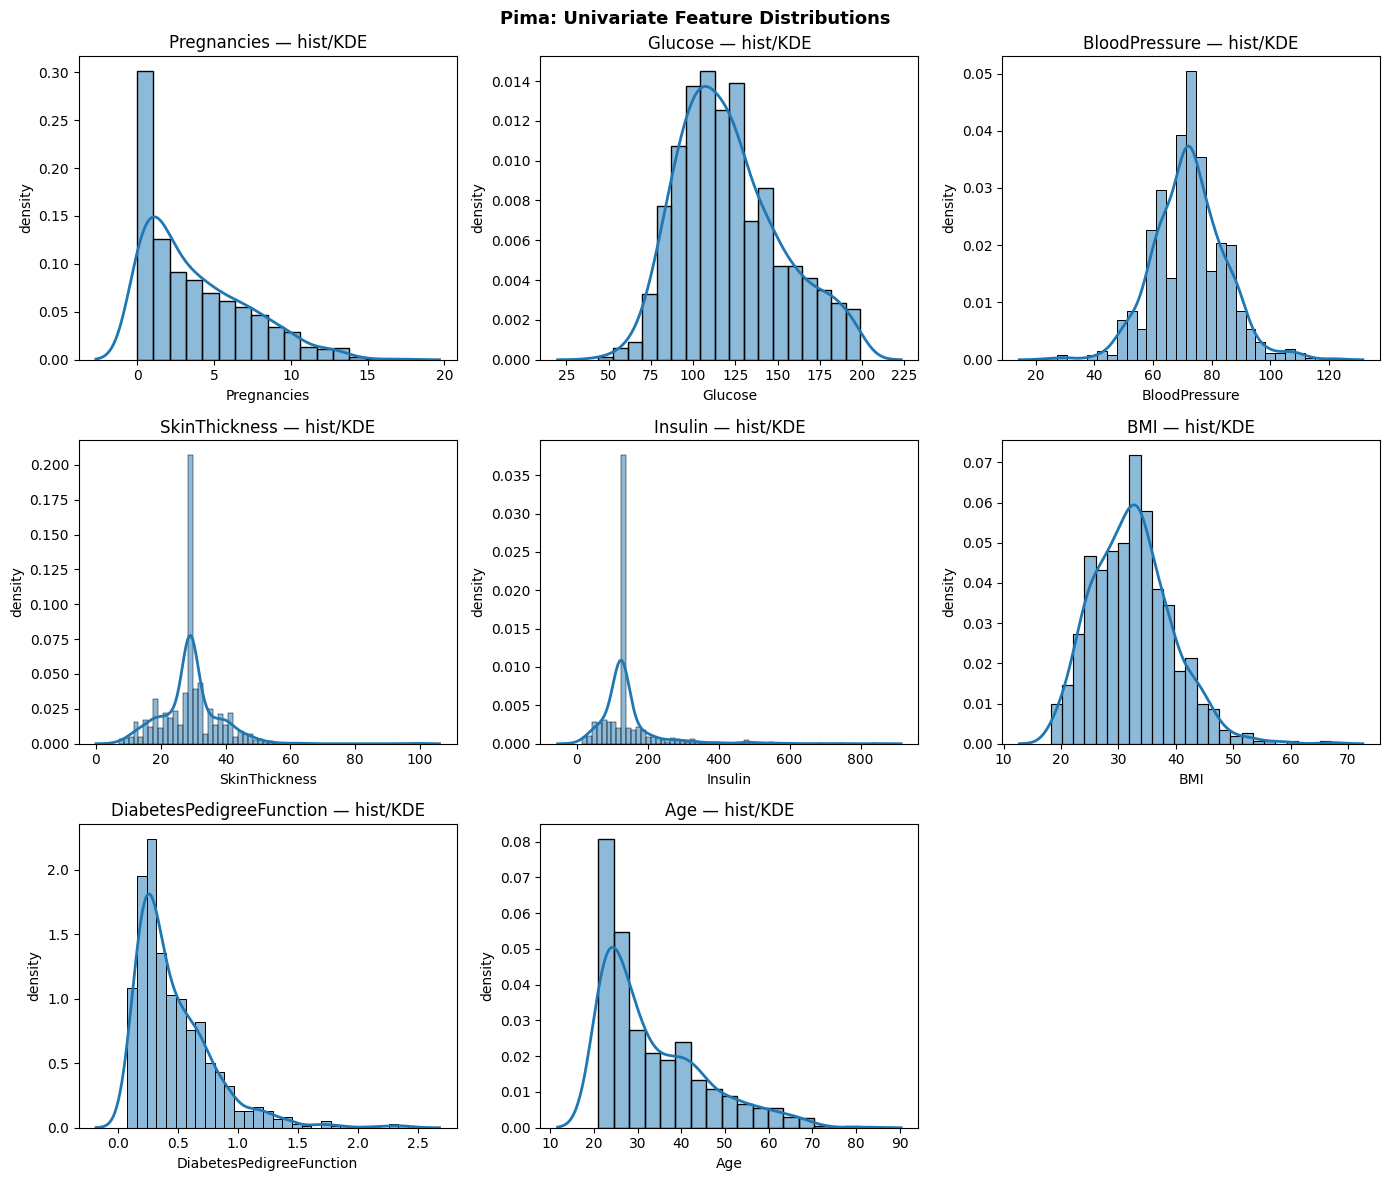

  Saved figure -> reports\eda\pima\class_balance_pima.png


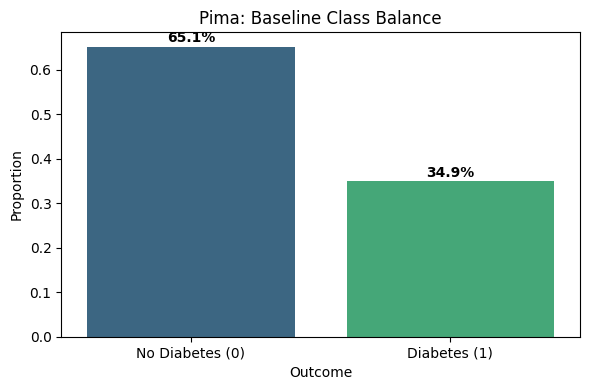


[7] Class balance — Healthy: 65.1% | Diabetic: 34.9%
  Saved figure -> reports\eda\pima\correlation_heatmap_pima.png


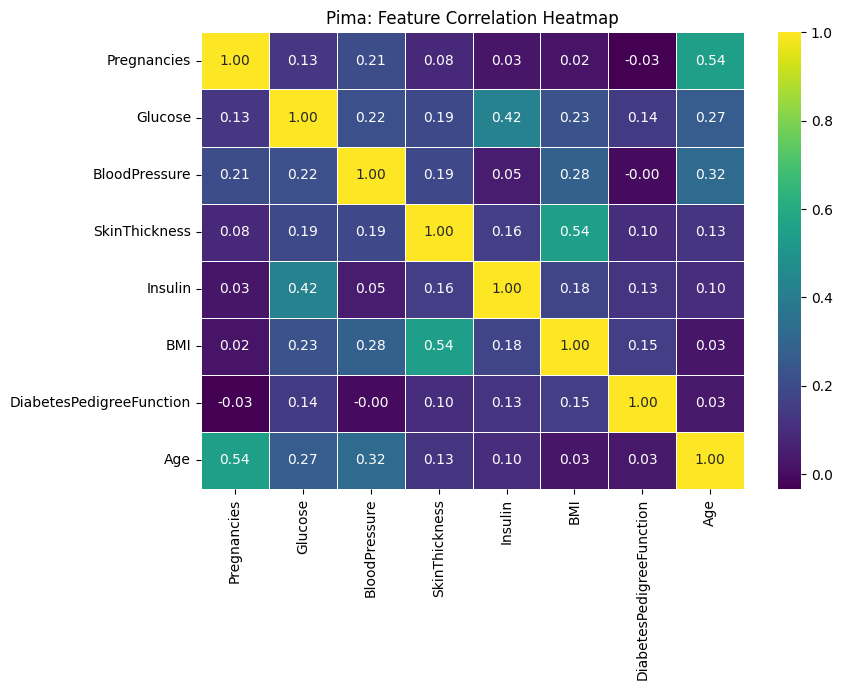

  Saved figure -> reports\eda\pima\boxplots_by_outcome_pima.png


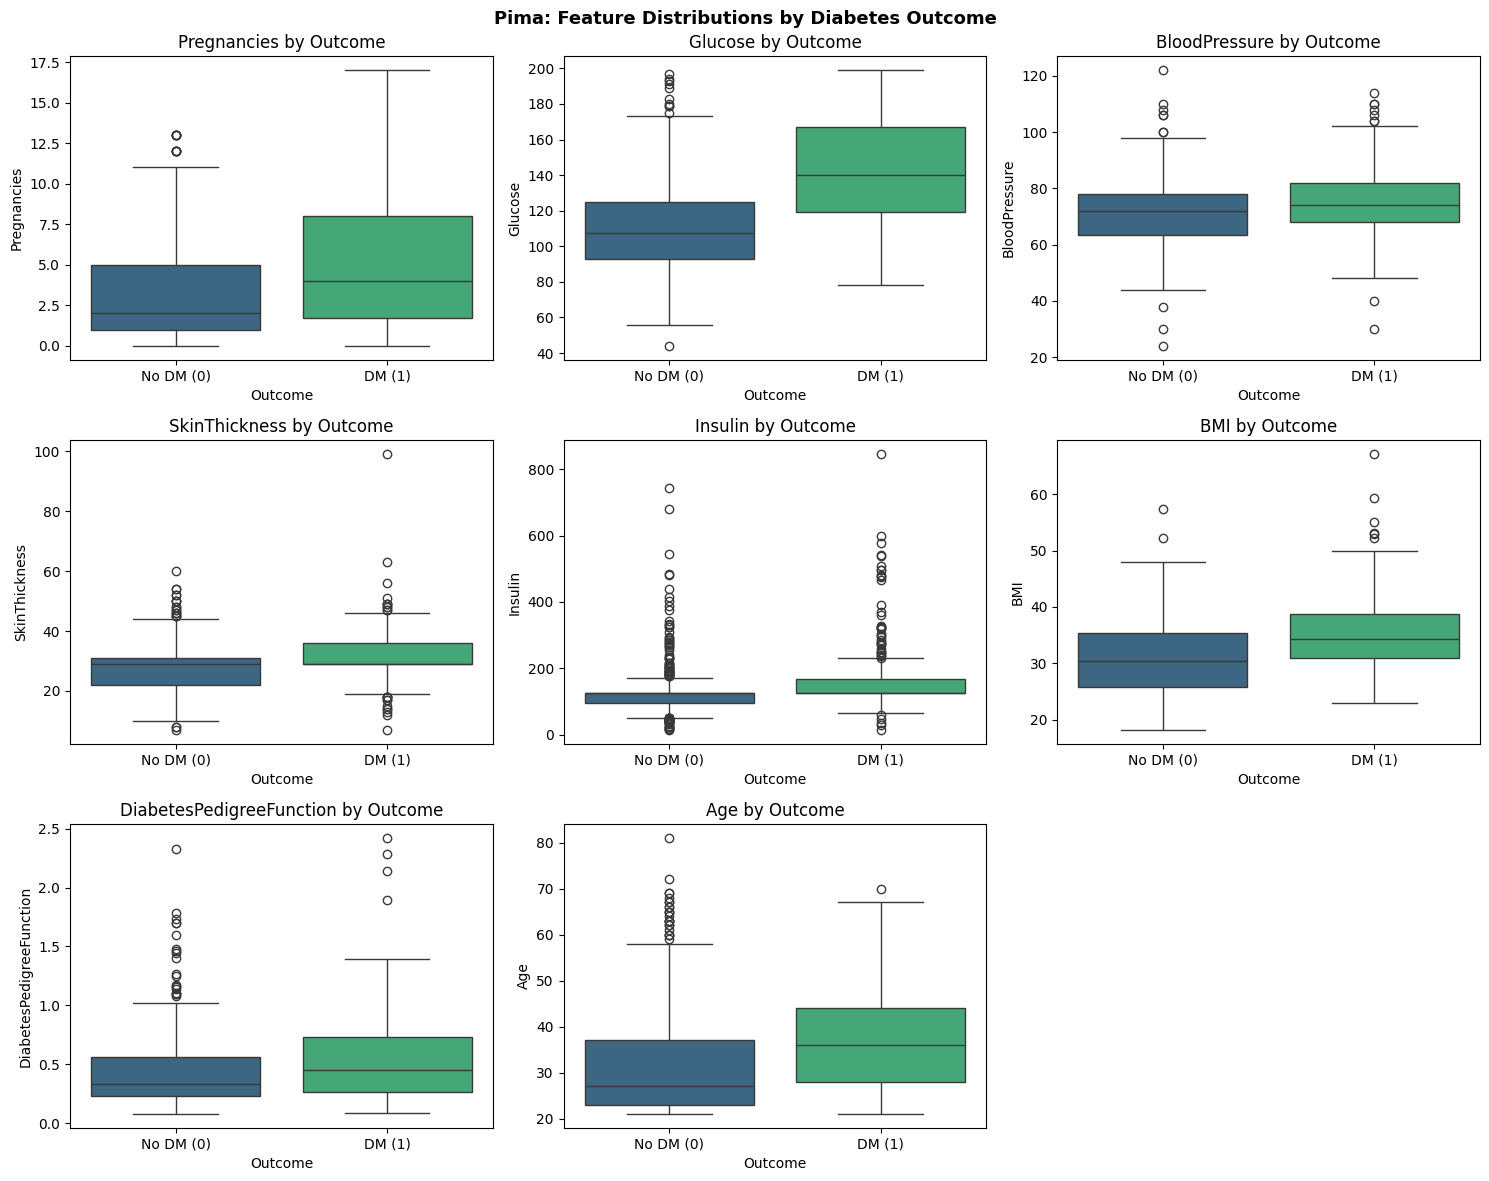


[10] Class-conditional statistics:


Outcome                     0           1
Pregnancies count  500.000000  268.000000
            mean     3.298000    4.865672
            std      3.017185    3.741239
            min      0.000000    0.000000
            25%      1.000000    1.750000
...                       ...         ...
Age         min     21.000000   21.000000
            25%     23.000000   28.000000
            50%     27.000000   36.000000
            75%     37.000000   44.000000
            max     81.000000   70.000000

[64 rows x 2 columns]

  Saved table  -> reports\eda\pima\class_conditional_summary_pima.csv

Key mean values (Glucose, BMI):


,Glucose,BMI
Outcome,,
0,110.68,30.89
1,142.13,35.38



[11] Statistical significance tests (H0: same distribution):


...


[2] Impossible-zero counts:


,zero_count
Glucose,13
BloodPressure,90
SkinThickness,573
Insulin,956
BMI,28



[3] step1_clean saved -> data\interim\fhgd_step1_clean.csv
    Missing values:
Pregnancies                   0
Glucose                      13
BloodPressure                90
SkinThickness               573
Insulin                     956
BMI                          28
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0

[4] step2_imputed saved -> data\interim\fhgd_step2_imputed.csv
    Remaining NaNs: 0

[5] Continuous features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,count,mean,std,min,max,skew
Pregnancies,2000.0,3.704,3.306,0.000,17.00,0.982
Glucose,2000.0,121.943,30.536,44.000,199.00,0.516
BloodPressure,2000.0,72.386,11.950,24.000,122.00,0.220
SkinThickness,2000.0,29.244,9.125,7.000,110.00,1.312
Insulin,2000.0,140.482,81.563,14.000,744.00,2.976
BMI,2000.0,32.647,7.190,18.200,80.60,0.937
DiabetesPedigreeFunction,2000.0,0.471,0.324,0.078,2.42,1.812
Age,2000.0,33.090,11.786,21.000,81.00,1.181


  Saved table  -> reports\eda\fhgd\univariate_summary_fhgd.csv
  Saved figure -> reports\eda\fhgd\univariate_panels_fhgd.png


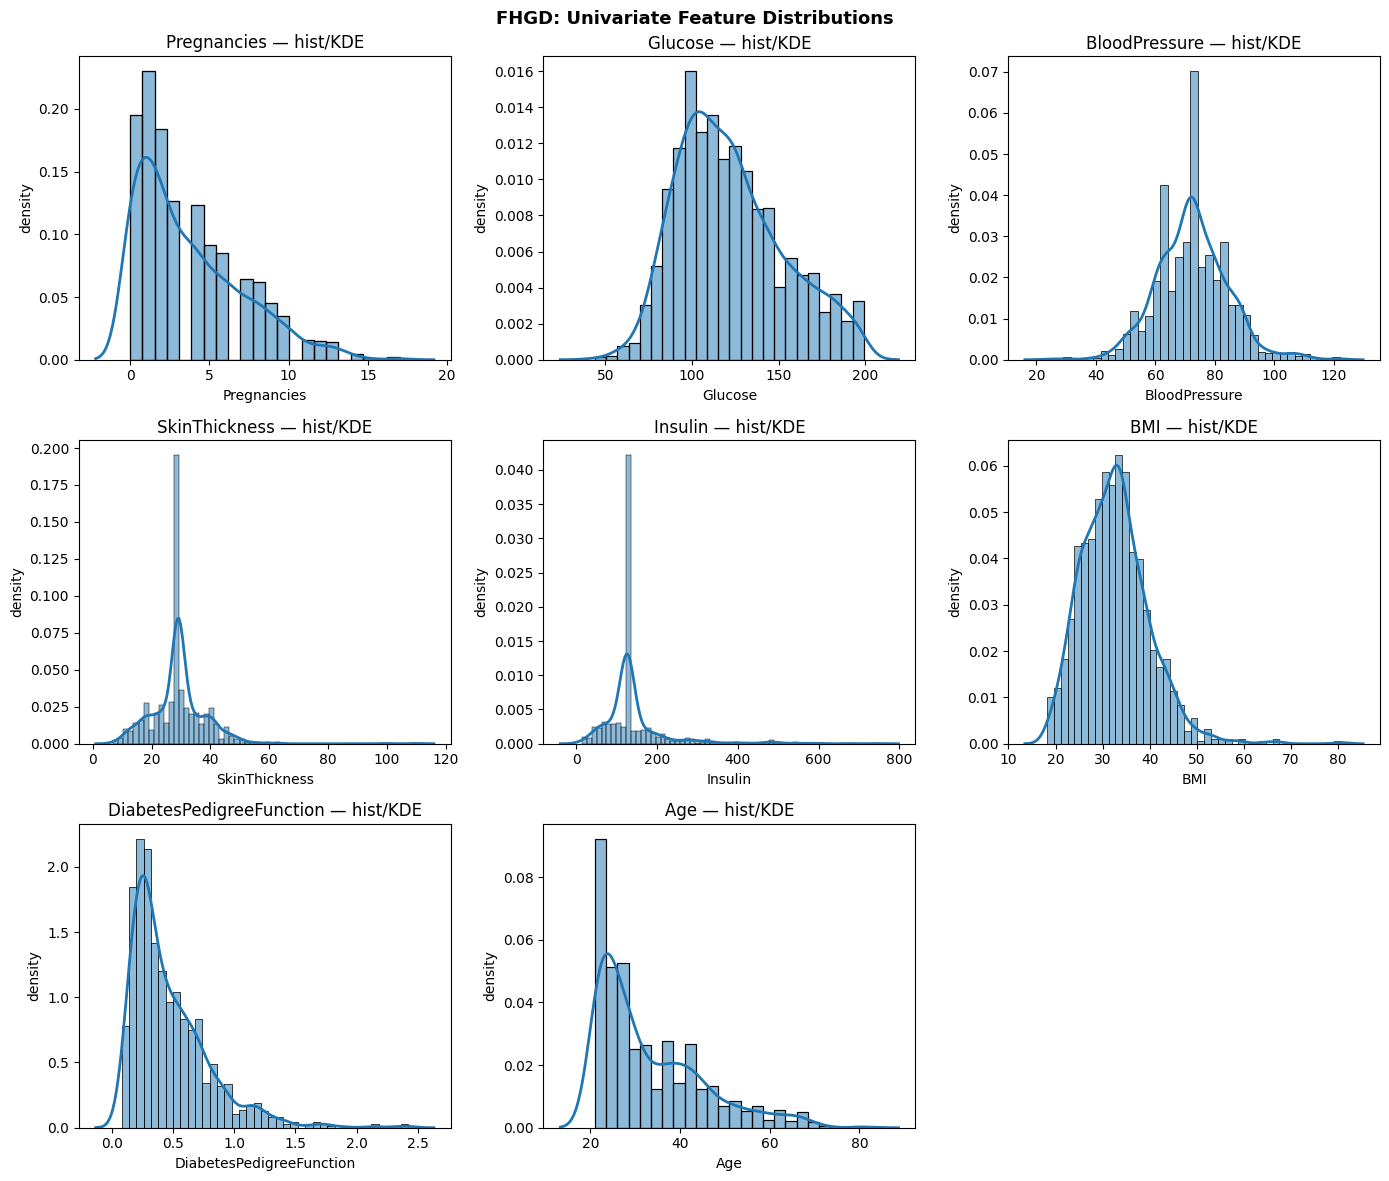

  Saved figure -> reports\eda\fhgd\class_balance_fhgd.png


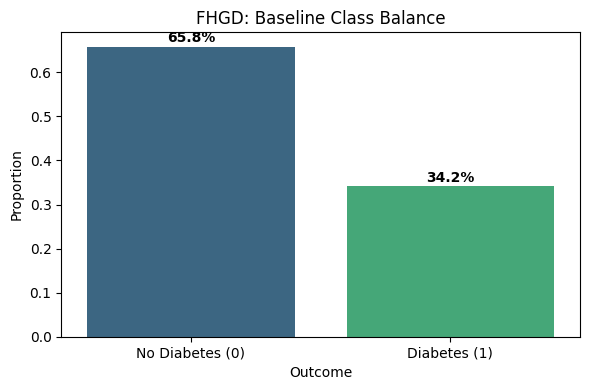


[7] Class balance — Healthy: 65.8% | Diabetic: 34.2%
  Saved figure -> reports\eda\fhgd\correlation_heatmap_fhgd.png


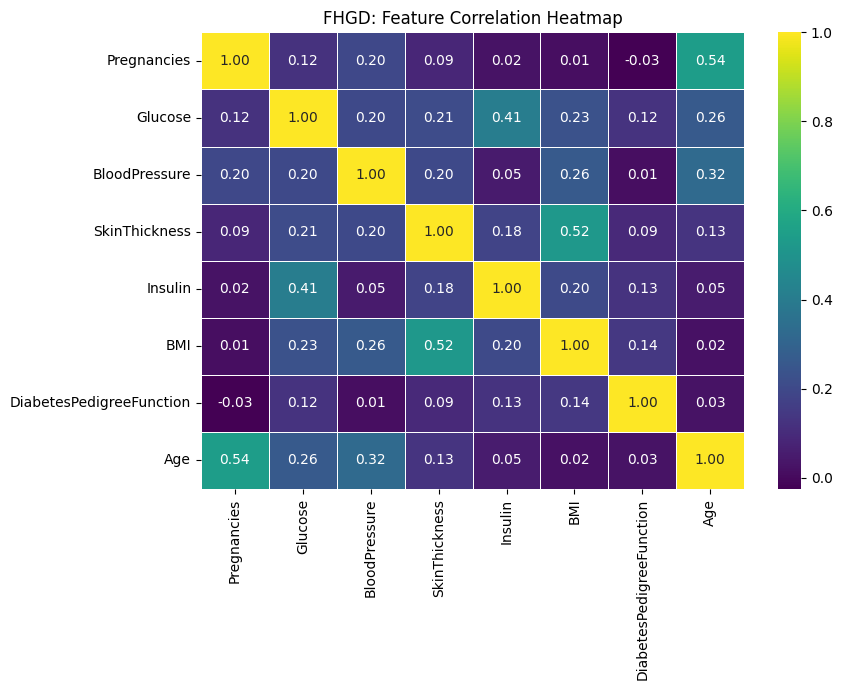

  Saved figure -> reports\eda\fhgd\boxplots_by_outcome_fhgd.png


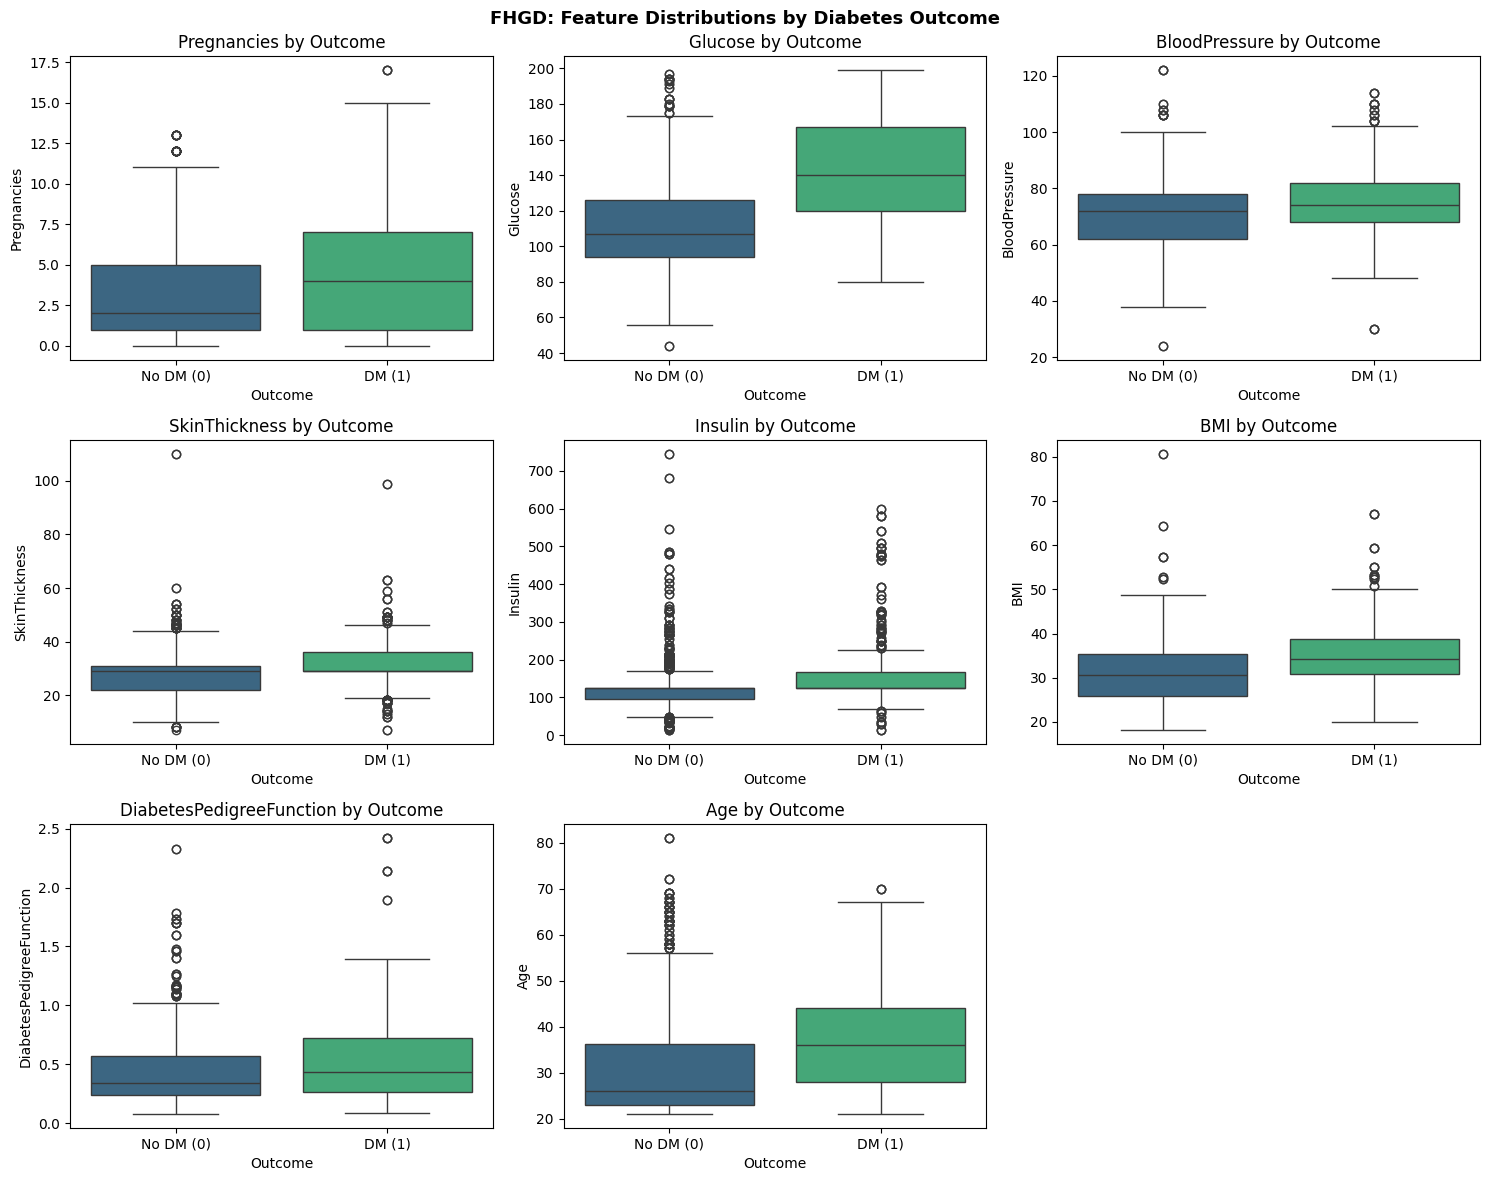


[10] Class-conditional statistics:


Outcome                      0           1
Pregnancies count  1316.000000  684.000000
            mean      3.168693    4.732456
            std       2.913526    3.746358
            min       0.000000    0.000000
            25%       1.000000    1.000000
...                        ...         ...
Age         min      21.000000   21.000000
            25%      23.000000   28.000000
            50%      26.000000   36.000000
            75%      36.250000   44.000000
            max      81.000000   70.000000

[64 rows x 2 columns]

  Saved table  -> reports\eda\fhgd\class_conditional_summary_fhgd.csv

Key mean values (Glucose, BMI):


,Glucose,BMI
Outcome,,
0,111.21,31.18
1,142.60,35.46



[11] Statistical significance tests (H0: same distribution):


,Feature,T-statistic,T-test p-value,KS-statistic,KS-test p-value
0,Pregnancies,-10.2947,0.0,0.2107,0.0
1,Glucose,-24.9715,0.0,0.4369,0.0
2,BloodPressure,-7.9067,0.0,0.1661,0.0
3,SkinThickness,-9.3463,0.0,0.1975,0.0
4,Insulin,-9.0048,0.0,0.2252,0.0
5,BMI,-13.1596,0.0,0.2868,0.0
6,DiabetesPedigreeFunction,-7.0344,0.0,0.1487,0.0
7,Age,-10.8804,0.0,0.3336,0.0


  Saved table  -> reports\eda\fhgd\statistical_tests_fhgd.csv

  FHGD EDA complete.
  Significant features (KS p<0.05): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [4]:
# ================================================================
# MAIN EDA LOOP — Runs identically for Pima and FHGD
# ================================================================
eda_summaries = {}   # store per-dataset summary stats for final comparison

for ds_name, cfg in DATASET_CONFIGS.items():

    print('\n' + '='*70)
    print(f'  DATASET: {ds_name} — {cfg["label"]}')
    print('='*70)

    tag      = cfg['interim_tag']
    fig_dir  = REPORTS_DIR / tag
    fig_dir.mkdir(parents=True, exist_ok=True)

    # ── 1. Load raw data ──────────────────────────────────────────────────────
    raw = pd.read_csv(cfg['raw_path'])
    print(f'\n[1] Raw data loaded  | shape: {raw.shape}')
    print(f'    Columns: {raw.columns.tolist()}')
    display(raw.head(3))
    display(raw.describe().round(2))

    # ── 2. Quantify hidden missing values (biological zeros) ──────────────────
    zero_counts = (raw[ZERO_COLS] == 0).sum().to_frame('zero_count')
    print('\n[2] Impossible-zero counts:')
    display(zero_counts)

    # ── 3. Replace zeros -> NaN and save step1_clean ──────────────────────────
    clean = raw.copy()
    clean[ZERO_COLS] = clean[ZERO_COLS].replace(0, np.nan)
    step1_path = INTERIM_DIR / f'{tag}_step1_clean.csv'
    clean.to_csv(step1_path, index=False)
    print(f'\n[3] step1_clean saved -> {step1_path}')
    print(f'    Missing values:\n{clean.isnull().sum().to_string()}')

    # ── 4. Missingness indicators + median imputation -> step2 ────────────────
    for col in ZERO_COLS:
        clean[f'{col}_is_missing'] = clean[col].isna().astype(int)

    imputed = clean.copy()
    imputed[ZERO_COLS] = imputed[ZERO_COLS].fillna(imputed[ZERO_COLS].median())
    step2_path = INTERIM_DIR / f'{tag}_step2_imputed.csv'
    imputed.to_csv(step2_path, index=False)
    print(f'\n[4] step2_imputed saved -> {step2_path}')
    print(f'    Remaining NaNs: {imputed.isnull().sum().sum()}')

    # ── 5. Feature selection for profiling ────────────────────────────────────
    all_num     = imputed.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in all_num if c != 'Outcome' and not c.endswith('_is_missing')]
    summary_stat = imputed[feature_cols].agg(['count','mean','std','min','max','skew']).T.round(3)
    print(f'\n[5] Continuous features: {feature_cols}')
    display(summary_stat)
    save_table(summary_stat.reset_index(), fig_dir, f'univariate_summary_{tag}')

    # ── 6. Univariate distribution plots (hist + KDE) ─────────────────────────
    ncols = 3
    nrows = ceil(len(feature_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
    axes = axes.ravel()
    for i, col in enumerate(feature_cols):
        data = imputed[col].dropna()
        bins = fd_bins(data)
        sns.histplot(data, bins=bins, stat='density', alpha=0.5, ax=axes[i])
        sns.kdeplot(data, ax=axes[i], lw=2)
        axes[i].set_title(f'{col} — hist/KDE')
        axes[i].set_xlabel(col); axes[i].set_ylabel('density')
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.suptitle(f'{ds_name}: Univariate Feature Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig(fig_dir, f'univariate_panels_{tag}')
    plt.show()

    # ── 7. Class balance ──────────────────────────────────────────────────────
    class_balance = imputed['Outcome'].value_counts(normalize=True)
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=class_balance.index, y=class_balance.values, ax=ax,
                palette='viridis', hue=class_balance.index, legend=False)
    ax.set_title(f'{ds_name}: Baseline Class Balance')
    ax.set_ylabel('Proportion'); ax.set_xlabel('Outcome')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])
    for idx, val in enumerate(class_balance):
        ax.text(idx, val + 0.01, f'{val:.1%}', ha='center', fontweight='bold')
    plt.tight_layout()
    save_fig(fig_dir, f'class_balance_{tag}')
    plt.show()
    print(f'\n[7] Class balance — Healthy: {class_balance[0]:.1%} | Diabetic: {class_balance[1]:.1%}')

    # ── 8. Correlation heatmap ────────────────────────────────────────────────
    corr = imputed[feature_cols].corr()
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis', linewidths=.5)
    plt.title(f'{ds_name}: Feature Correlation Heatmap')
    plt.tight_layout()
    save_fig(fig_dir, f'correlation_heatmap_{tag}')
    plt.show()

    # ── 9. Box plots by outcome ───────────────────────────────────────────────
    nrows2 = ceil(len(feature_cols) / ncols)
    fig, axes = plt.subplots(nrows2, ncols, figsize=(15, 4*nrows2))
    axes = axes.ravel()
    for i, col in enumerate(feature_cols):
        sns.boxplot(data=imputed, x='Outcome', y=col, ax=axes[i],
                    palette='viridis', hue='Outcome', legend=False)
        axes[i].set_title(f'{col} by Outcome')
        axes[i].set_xticks([0,1]); axes[i].set_xticklabels(['No DM (0)', 'DM (1)'])
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f'{ds_name}: Feature Distributions by Diabetes Outcome',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig(fig_dir, f'boxplots_by_outcome_{tag}')
    plt.show()

    # ── 10. Class-conditional statistics ─────────────────────────────────────
    class_stats = imputed.groupby('Outcome')[feature_cols].describe()
    print(f'\n[10] Class-conditional statistics:')
    display(class_stats.T)
    save_table(class_stats.T.reset_index(), fig_dir, f'class_conditional_summary_{tag}')
    print('\nKey mean values (Glucose, BMI):')
    display(imputed.groupby('Outcome')[['Glucose', 'BMI']].mean().round(2))

    # ── 11. Statistical significance tests (T-test + K-S) ────────────────────
    g0 = imputed[imputed['Outcome'] == 0]
    g1 = imputed[imputed['Outcome'] == 1]
    test_rows = []
    for col in feature_cols:
        t_stat, t_p = ttest_ind(g0[col], g1[col])
        ks_stat, ks_p = ks_2samp(g0[col], g1[col])
        test_rows.append({'Feature': col, 'T-statistic': round(t_stat,4),
                          'T-test p-value': t_p, 'KS-statistic': round(ks_stat,4),
                          'KS-test p-value': ks_p})
    results_df = pd.DataFrame(test_rows)
    print(f'\n[11] Statistical significance tests (H0: same distribution):')
    display(results_df.round(6))
    save_table(results_df, fig_dir, f'statistical_tests_{tag}')

    # ── Store summary for cross-dataset comparison ────────────────────────────
    eda_summaries[ds_name] = {
        'n_total'       : len(raw),
        'n_features'    : len(feature_cols),
        'class_balance' : dict(class_balance),
        'summary_stats' : summary_stat,
        'sig_features'  : results_df[results_df['KS-test p-value'] < 0.05]['Feature'].tolist(),
    }
    print(f'\n{"="*70}')
    print(f'  {ds_name} EDA complete.')
    print(f'  Significant features (KS p<0.05): {eda_summaries[ds_name]["sig_features"]}')
    print(f'{"="*70}')

In [5]:
# ================================================================
# CROSS-DATASET SUMMARY COMPARISON
# ================================================================
print('\nCROSS-DATASET SUMMARY')
print('='*50)
for ds, info in eda_summaries.items():
    print(f'\n{ds}:')
    print(f'  Samples       : {info["n_total"]}')
    print(f'  Features      : {info["n_features"]}')
    print(f'  Class balance : Healthy={info["class_balance"][0]:.1%} | Diabetic={info["class_balance"][1]:.1%}')
    print(f'  Sig. features : {info["sig_features"]}')

print('\nAll interim files saved to data/interim/')
print('EDA complete for both cohorts.')


CROSS-DATASET SUMMARY

Pima:
  Samples       : 768
  Features      : 8
  Class balance : Healthy=65.1% | Diabetic=34.9%
  Sig. features : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

FHGD:
  Samples       : 2000
  Features      : 8
  Class balance : Healthy=65.8% | Diabetic=34.2%
  Sig. features : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

All interim files saved to data/interim/
EDA complete for both cohorts.
